### Question 1: From Prices to Returns

In [20]:
!pip install pandas
!pip install matplotlib
!pip install statsmodels

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import warnings

warnings.filterwarnings("ignore")


# Load pre-processed data with date index
stock_excess = pd.read_csv("./processed_data/stock_excess_monthly.csv", index_col=0)
# Market excess and risk-free rate are single columns; read as Series aligned on the same date index
mkt_excess = pd.read_csv("./processed_data/mkt_excess_monthly.csv", index_col=0)[
    "mkt_excess"
]
rf_m = pd.read_csv("./processed_data/rf_monthly.csv", index_col=0)["rf"]

### Task (a)


In [22]:
# Task (a): construct a monthly excess-return panel from the pre-processed data

# `stock_excess` already contains monthly stock excess returns (columns = tickers, index = date)
# `mkt_excess` is the corresponding monthly market excess return series.
# These tasks were completed in the data pre-processing file.

# Combine stock and market excess returns into a single DataFrame.
log_returns = stock_excess.copy()
log_returns["mkt_excess"] = mkt_excess

# Drop any months where the market excess return is missing.
log_returns = log_returns.dropna(subset=["mkt_excess"])

log_returns.head()

,A,AAPL,ABBV,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,...,WY,WYNN,XEL,XOM,XYL,YUM,ZBH,ZBRA,ZTS,mkt_excess
2015-03-31,-0.009829,-0.034014,-0.030641,-0.016088,0.035693,0.028604,-0.050217,0.074302,0.005257,-0.006663,...,-0.034745,-0.099366,0.014444,-0.026841,-0.020469,-0.018646,-0.012013,-0.004928,-0.000220,-0.016226
2015-04-30,-0.005942,0.004169,0.106092,0.005443,-0.016648,-0.002125,0.026668,-0.020185,0.029145,-0.014528,...,-0.052338,-0.126769,-0.027795,0.025900,0.053939,0.091635,-0.069184,0.013280,-0.041043,0.006884
2015-05-31,-0.006086,0.042616,0.027686,0.044168,0.049823,0.034211,0.037339,0.098645,0.081648,0.009683,...,0.031055,-0.095432,0.002395,-0.018639,-0.010135,0.045424,0.038199,0.172819,0.111997,0.008712
2015-06-30,-0.065001,-0.039978,0.006930,0.007788,0.044893,0.005636,0.021947,-0.059111,-0.093723,-0.059866,...,-0.026151,-0.022305,-0.048630,-0.025793,0.011540,-0.002373,-0.045571,0.010739,-0.033678,-0.023275
2015-07-31,0.057611,-0.035487,0.046502,0.035089,0.061636,0.061349,0.010019,-0.097737,-0.018736,-0.007756,...,-0.028057,0.043172,0.072524,-0.051151,-0.072986,-0.023631,-0.050398,-0.033287,0.013632,0.017544


### Task (b)

In [23]:
# Align the monthly risk-free rate (rf_m) to the excess-return panel.
# `rf_m` is a Series indexed by the same monthly dates.
rf_aligned = pd.DataFrame({"rf": rf_m.loc[log_returns.index]})

# Inspect the aligned risk-free rate.
rf_aligned.head()

,rf
2015-03-31,0.001517
2015-04-30,0.001600
2015-05-31,0.001725
2015-06-30,0.002039
2015-07-31,0.002006


In [24]:
# Check for missing values in the aligned monthly risk-free rate.
missing_rf = rf_aligned["rf"].isna().sum()
print(f"Missing rf values: {missing_rf}")

# Forward fill missing rf values if any.
rf_aligned["rf"] = rf_aligned["rf"].ffill()

print(f"Missing rf values after ffill: {rf_aligned['rf'].isna().sum()}")

Missing rf values: 0
Missing rf values after ffill: 0


In [25]:
# The series `rf` is already a monthly risk-free rate derived from DGS10.
# For later use we will keep it as-is and also compute its average.
mean_rf_monthly = rf_aligned["rf"].mean()

rf_aligned.head()

,rf
2015-03-31,0.001517
2015-04-30,0.001600
2015-05-31,0.001725
2015-06-30,0.002039
2015-07-31,0.002006


In [26]:
# Isolate only the stock excess-return columns for matrix operations.
returns_only = log_returns[stock_excess.columns]

# 1) Compute Annualized Expected Excess Returns (mu_hat)
# The columns in `returns_only` are monthly *excess* log returns that were
# constructed in `Data_Pre_Processing.ipynb` by first computing *daily* log
# returns, then summing them within each month and subtracting the monthly
# risk-free rate. For such monthly sums of daily log returns, we have the
# equivalence:
#   252 * (mean daily log return)  ==  12 * (mean monthly log return).
# Thus, multiplying the monthly excess-return mean by 12 produces the same
# annualized expected excess return as the formula in the assignment handout.
mu_hat = 12 * returns_only.mean()

# 2) Compute Annualized Covariance Matrix (sigma_hat)
# For the same reason, the annualized covariance matrix can be obtained as
# 12 times the covariance matrix of monthly excess returns, which is
# equivalent to 252 times the daily covariance matrix used upstream.
sigma_hat = 12 * returns_only.cov()

# Reporting
print(f"mu_hat shape: {mu_hat.shape}")
print(f"sigma_hat shape: {sigma_hat.shape}")
print("mu_hat (first 5):\n", mu_hat.head())
print("sigma_hat (top-left 5x5):\n", sigma_hat.iloc[:5, :5])

mu_hat shape: (472,)
sigma_hat shape: (472, 472)
mu_hat (first 5):
 A       0.090355
AAPL    0.184475
ABBV    0.139531
ABT     0.100968
ACGL    0.132852
dtype: float64
sigma_hat (top-left 5x5):
              A      AAPL      ABBV       ABT      ACGL
A     0.062311  0.026612  0.023499  0.030200  0.016727
AAPL  0.026612  0.073744  0.008053  0.022621  0.014229
ABBV  0.023499  0.008053  0.065017  0.019037  0.012242
ABT   0.030200  0.022621  0.019037  0.041945  0.005171
ACGL  0.016727  0.014229  0.012242  0.005171  0.060035


# Question 3

In [27]:
sigma_inv = np.linalg.inv(sigma_hat)
ones = np.ones(len(mu_hat))

A = ones @ sigma_inv @ mu_hat
B = mu_hat @ sigma_inv @ mu_hat
C = ones @ sigma_inv @ ones
D = B * C - A**2

In [28]:
def mv_weights(mu_target):
    lam_1 = (C * mu_target - A) / D
    lam_2 = (B - A * mu_target) / D
    return sigma_inv @ (lam_1 * mu_hat + lam_2 * ones)

## GMV Portfolio

In [29]:
mu_gmv = A / C
sigma_gmv = np.sqrt(1 / C)

## Frontier

In [30]:
mu_grid = np.linspace(mu_gmv, mu_hat.values.max() * 1.2, 300)
sigma_grid = np.sqrt((C * mu_grid**2 - 2*A*mu_grid + B) / D)

In [31]:
asset_sigma = np.sqrt(np.diag(sigma_hat.values))
asset_mu = mu_hat.values
tickers = mu_hat.index.tolist()

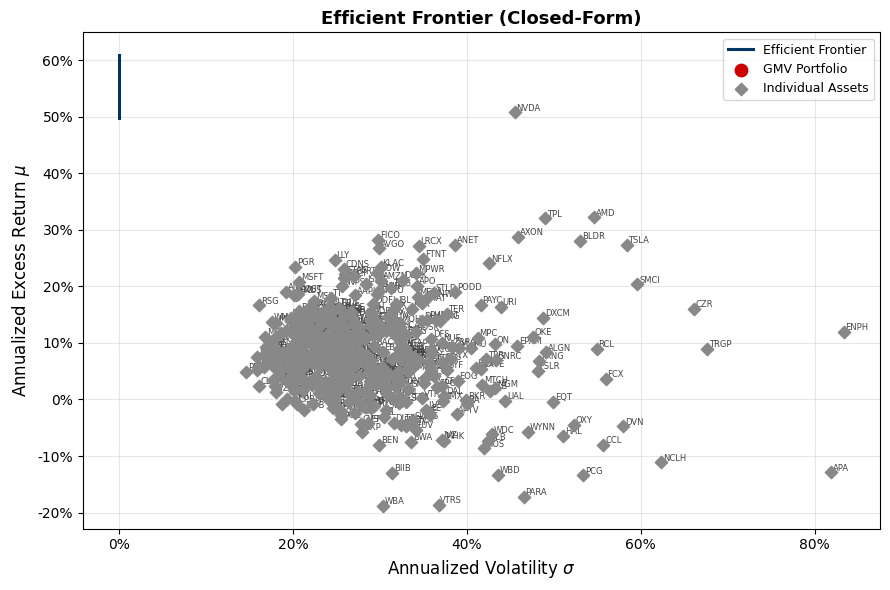

In [32]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(sigma_grid, mu_grid, color="#003366", linewidth=2.2, label="Efficient Frontier")

ax.scatter(sigma_gmv, mu_gmv, color="#cc0000", zorder=5, s=80, label="GMV Portfolio")
ax.annotate("GMV", xy=(sigma_gmv, mu_gmv),
            xytext=(sigma_gmv + 0.005, mu_gmv - 0.01),
            fontsize=8, color="#cc0000")

ax.scatter(asset_sigma, asset_mu, color="#888888", zorder=4, s=40,
           marker="D", label="Individual Assets")
for i, t in enumerate(tickers):
    ax.annotate(t, xy=(asset_sigma[i], asset_mu[i]),
                xytext=(asset_sigma[i] + 0.002, asset_mu[i] + 0.003),
                fontsize=6, color="#444444")

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.set_xlabel("Annualized Volatility $\\sigma$", fontsize=12)
ax.set_ylabel("Annualized Excess Return $\\mu$", fontsize=12)
ax.set_title("Efficient Frontier (Closed-Form)", fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## 3c)

## GMV Portfolio

In [33]:
w_gmv  = sigma_inv @ ones / C
mu_gmv = w_gmv @ mu_hat.values
sigma_gmv = np.sqrt(w_gmv @ sigma_hat.values @ w_gmv)

print("GMV Portfolio")
print(f"Expected Return: {mu_gmv:.2%}")
print(f"Std Deviation: {sigma_gmv:.2%}")
print(f"Weights:")
gmv_weights = pd.Series(w_gmv, index=mu_hat.index).sort_values(ascending=False)
print(gmv_weights.to_string())
print(f"Long positions: {(w_gmv > 0).sum()}")
print(f"Short positions: {(w_gmv < 0).sum()}")

GMV Portfolio
Expected Return: 15.89%
Std Deviation: 0.00%
Weights:
GILD     0.458754
SJM      0.443536
WM       0.431996
SYK      0.405256
PGR      0.395473
PNW      0.388773
PG       0.369755
D        0.361686
CPB      0.352750
ATO      0.351371
EG       0.348841
CDNS     0.338588
XEL      0.315089
MDT      0.309173
FRT      0.305186
TYL      0.304675
EVRG     0.303211
ES       0.301655
ADP      0.300656
ALLE     0.286639
JNPR     0.275208
LLY      0.272747
CL       0.259704
LOW      0.258918
EA       0.251676
PPG      0.251589
PWR      0.250184
BDX      0.248568
MSCI     0.246696
BXP      0.246349
MAA      0.243077
EPAM     0.239470
SPG      0.235529
TMUS     0.234209
FMC      0.229772
RVTY     0.227022
ESS      0.225331
VRSN     0.216103
DHR      0.213785
WMT      0.210500
TFC      0.200369
WELL     0.199976
PFE      0.199744
AON      0.198792
MPWR     0.197123
CRM      0.196143
PHM      0.194438
JKHY     0.190486
EBAY     0.190320
HIG      0.190289
BK       0.190245
CB       0.190

## Tangency Portfolio

In [34]:
w_tan_raw = sigma_inv @ mu_hat.values
w_tan = w_tan_raw / (ones @ w_tan_raw)

mu_tan = w_tan @ mu_hat.values
sigma_tan = np.sqrt(w_tan @ sigma_hat.values @ w_tan)
sharpe_tan = mu_tan / sigma_tan

In [35]:
print("\nTangency Portfolio")
print(f"Expected Return: {mu_tan:.2%}")
print(f"Std Deviation: {sigma_tan:.2%}")
print(f"Sharpe Ratio: {sharpe_tan:.4f}")
print(f"Weights:")
tan_weights = pd.Series(w_tan, index=mu_hat.index).sort_values(ascending=False)
print(tan_weights.to_string())
print(f"Long positions: {(w_tan > 0).sum()}")
print(f"Short positions: {(w_tan < 0).sum()}")


Tangency Portfolio
Expected Return: 9.79%
Std Deviation: nan%
Sharpe Ratio: nan
Weights:
JNPR     1.136971
D        1.026430
AEP      0.898212
EA       0.885423
LII      0.868437
CL       0.832152
AON      0.828960
KO       0.765629
BDX      0.739693
HSY      0.732361
WELL     0.731467
TYL      0.710363
UDR      0.705691
FRT      0.701658
WM       0.675240
PWR      0.668550
DAL      0.622368
CB       0.601730
SJM      0.595209
LIN      0.593222
PNW      0.589268
NKE      0.584836
KEY      0.569717
WY       0.558060
VRSN     0.554265
CTSH     0.539770
MAA      0.537057
EG       0.534049
EVRG     0.522851
BX       0.521636
TFC      0.502525
PHM      0.499124
GILD     0.495052
NWS      0.483483
RVTY     0.473723
SYK      0.472170
TMUS     0.471467
AEE      0.455396
ADM      0.444337
ALLE     0.443163
WMT      0.438500
INTC     0.433364
CNC      0.421907
INTU     0.416055
HPQ      0.413082
CMS      0.406373
IQV      0.395749
BK       0.395100
ANSS     0.395078
A        0.389753
CPB      0

# Question 3.2

In [36]:
!pip install cvxpy

  Using cached cvxpy-1.8.1-cp311-cp311-macosx_10_9_universal2.whl.metadata (9.6 kB)
  Using cached osqp-1.1.1-cp311-cp311-macosx_11_0_arm64.whl.metadata (2.2 kB)
  Using cached clarabel-0.11.1-cp39-abi3-macosx_11_0_arm64.whl.metadata (4.8 kB)
  Using cached scs-3.2.11-cp311-cp311-macosx_11_0_arm64.whl.metadata (2.8 kB)
  Using cached highspy-1.13.1-cp311-cp311-macosx_11_0_arm64.whl.metadata (11 kB)
  Using cached cffi-2.0.0-cp311-cp311-macosx_11_0_arm64.whl.metadata (2.6 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached pycparser-3.0-py3-none-any.whl.metadata (8.2 kB)
  Using cached markupsafe-3.0.3-cp311-cp311-macosx_11_0_arm64.whl.metadata (2.7 kB)
Using cached cvxpy-1.8.1-cp311-cp311-macosx_10_9_universal2.whl (1.7 MB)
Using cached clarabel-0.11.1-cp39-abi3-macosx_11_0_arm64.whl (935 kB)
Using cached highspy-1.13.1-cp311-cp311-macosx_11_0_arm64.whl (2.0 MB)
Using cached osqp-1.1.1-cp311-cp

## Using cvxpy to solve the Std. Dev Minimization Problem (GMV)

In [38]:
import cvxpy as cp
n = len(mu_hat)
w = cp.Variable(n)
objective = cp.Minimize(cp.quad_form(w, sigma_hat))
constraints = [
    cp.sum(w) == 1
]
problem = cp.Problem(objective, constraints)
solution = problem.solve(solver=cp.OSQP, polish=True)

## Checking if the Solution matches

In [39]:
print(f"Std. Dev: {np.sqrt(solution)*100:.2f}%")

Std. Dev: nan%


## Adding Long-Only Constraint

In [40]:
n = len(mu_hat)
w = cp.Variable(n)
objective = cp.Minimize(cp.quad_form(w, sigma_hat))
constraints = [
    cp.sum(w) == 1,
    w >= 0
]
problem = cp.Problem(objective, constraints)
solution = problem.solve(solver=cp.OSQP, polish=True)

print(f"Std. Dev: {np.sqrt(solution)*100:.2f}%")

Std. Dev: 8.51%
